##  [ 2025년 데이터분석경진대회 범죄율 데이터 시각화]
##  - 데이터제공 : crime.csv

## 1. 필요 라이브러리 선언

In [1]:
import pandas as pd  
import numpy as np  #연산
import seaborn as sns  #시각화
import matplotlib as mpl #시각화
import matplotlib.pyplot as plt  #차트 플롯
import matplotlib.font_manager as fm  #폰트 설정

## 2. 폰트 설정

In [2]:
# 폰트 설정
mpl.rc('font', family='Malgun Gothic') # 맑은고딕으로 폰트 지정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

## 3. 데이터 불러오기  [ col 어떤 것이 있는지 확인하기 ]

In [3]:
# csv 파일 불러오기 (한글 데이터이므로 cp949 인코딩 사용)
df = pd.read_csv('crime.csv', encoding='cp949')

print(df.shape)   # (행, 열) 개수 확인
df.head()         # 데이터 미리보기

(38, 36)


,범죄대분류,범죄중분류,아파트-연립다세대,단독주택,고속도로,노상,백화점,슈퍼마켓,편의점,대형할인매장,...,종교기관,산야,해상,부대,구금장소,공지,주차장,공중화장실,피씨방,기타
0,강력범죄,살인기수,111,80,0,42,0,0,0,0,...,3,5,0,0,0,1,2,1,0,20
1,강력범죄,살인미수등,99,92,0,96,0,1,1,1,...,1,2,3,0,0,0,11,1,0,28
2,강력범죄,강도,77,54,1,164,1,17,68,1,...,1,4,0,0,0,0,19,0,3,34
3,강력범죄,강간,1516,958,3,157,0,0,5,0,...,10,12,1,0,0,0,37,44,3,299
4,강력범죄,유사강간,229,131,0,43,0,0,3,0,...,2,1,0,1,2,0,7,8,0,64


## 4. col에 어떤 것이 있는지 출력

In [4]:
# 데이터프레임의 컬럼(col) 목록 확인
print(df.columns)
df.columns.tolist()

Index(['범죄대분류', '범죄중분류', '아파트-연립다세대', '단독주택', '고속도로', '노상', '백화점', '슈퍼마켓',
       '편의점', '대형할인매장', '상점', '시장-노점', '숙박업소-목욕탕', '유흥접객업소', '사무실', '공장',
       '공사장-광산', '창고', '역-대합실', '지하철', '기타표통수단내', '흥행장', '유원지', '학교', '금융기관',
       '의료기관', '종교기관', '산야', '해상', '부대', '구금장소', '공지', '주차장', '공중화장실', '피씨방',
       '기타'],
      dtype='str')


['범죄대분류',
 '범죄중분류',
 '아파트-연립다세대',
 '단독주택',
 '고속도로',
 '노상',
 '백화점',
 '슈퍼마켓',
 '편의점',
 '대형할인매장',
 '상점',
 '시장-노점',
 '숙박업소-목욕탕',
 '유흥접객업소',
 '사무실',
 '공장',
 '공사장-광산',
 '창고',
 '역-대합실',
 '지하철',
 '기타표통수단내',
 '흥행장',
 '유원지',
 '학교',
 '금융기관',
 '의료기관',
 '종교기관',
 '산야',
 '해상',
 '부대',
 '구금장소',
 '공지',
 '주차장',
 '공중화장실',
 '피씨방',
 '기타']

## 5. '범죄대분류'만 다시 unique

In [5]:
# '범죄대분류' 컬럼에서 중복 제거 후 어떤 값들이 있는지 확인
df['범죄대분류'].unique()

<StringArray>
[  '강력범죄',   '절도범죄',   '폭력범죄',   '지능범죄',   '풍속범죄', '특별경제범죄',   '마약범죄',
   '보건범죄',   '환경범죄',   '교통범죄',   '노동범죄',   '안보범죄',   '선거범죄',   '병역범죄',
   '기타범죄']
Length: 15, dtype: str

## 6. 범죄대분류 최대 빈도수 분석 [ 그룹화 : groupby ]

In [6]:
# 범죄대분류로 그룹화하여 각 대분류에 속한 범죄중분류 개수(빈도수) 확인
crime_count = df.groupby('범죄대분류').size()
print(crime_count.sort_values(ascending=False))

print()
print('최대 빈도수 범죄대분류 :', crime_count.idxmax(), '(', crime_count.max(), '개)')

범죄대분류
지능범죄      9
폭력범죄      8
강력범죄      8
풍속범죄      2
노동범죄      1
교통범죄      1
기타범죄      1
보건범죄      1
병역범죄      1
마약범죄      1
선거범죄      1
절도범죄      1
안보범죄      1
특별경제범죄    1
환경범죄      1
dtype: int64

최대 빈도수 범죄대분류 : 지능범죄 ( 9 개)


## 7. 범죄대분류별 합계 sum

In [7]:
# 범죄대분류별로 모든 장소(col) 값을 합산하여 전체 발생 건수(합계) 구하기
crime_total = df.groupby('범죄대분류').sum(numeric_only=True).sum(axis=1)
crime_total

범죄대분류
강력범죄       24332
교통범죄      348725
기타범죄      241829
노동범죄         356
마약범죄        9186
병역범죄        3845
보건범죄       14595
선거범죄         829
안보범죄         216
절도범죄      179517
지능범죄      424642
특별경제범죄     47826
폭력범죄      265768
풍속범죄       22632
환경범죄        3568
dtype: int64

## 8. 범죄대분류별 합계 및 내림차순
### [ 인덱스(index) 재설정 ] [ col 이름 변경 ]

In [8]:
# 합계 기준 내림차순 정렬 + 인덱스 재설정 + 컬럼 이름 변경
crime_total_df = crime_total.sort_values(ascending=False).reset_index()
crime_total_df.columns = ['범죄대분류', '합계']
crime_total_df

,범죄대분류,합계
0,지능범죄,424642
1,교통범죄,348725
2,폭력범죄,265768
3,기타범죄,241829
4,절도범죄,179517
5,특별경제범죄,47826
6,강력범죄,24332
7,풍속범죄,22632
8,보건범죄,14595
9,마약범죄,9186


# 9. 최대 빈도수의 범죄대분류 리스트 생성

In [9]:
# 합계가 큰 순서대로 정렬된 범죄대분류 이름들을 리스트로 생성
top_crime_list = crime_total_df['범죄대분류'].tolist()
top_crime_list

['지능범죄',
 '교통범죄',
 '폭력범죄',
 '기타범죄',
 '절도범죄',
 '특별경제범죄',
 '강력범죄',
 '풍속범죄',
 '보건범죄',
 '마약범죄',
 '병역범죄',
 '환경범죄',
 '선거범죄',
 '노동범죄',
 '안보범죄']

## 10. 막대 그래프 시각화 [ 상위 5개 출력 ] 

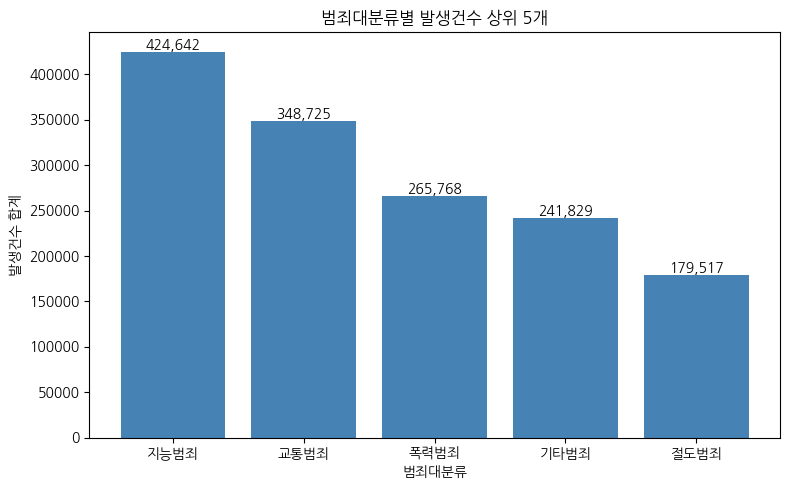

In [10]:
# 합계 기준 상위 5개 범죄대분류만 추출
top5 = crime_total_df.head(5)

plt.figure(figsize=(8, 5))
bars = plt.bar(top5['범죄대분류'], top5['합계'], color='steelblue')
plt.title('범죄대분류별 발생건수 상위 5개')
plt.xlabel('범죄대분류')
plt.ylabel('발생건수 합계')

# 막대 위에 값(합계) 표시
for bar, value in zip(bars, top5['합계']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:,}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 11. '지능범죄' 중 범죄중분류 최대 빈도수 분석

In [11]:
# 특정 범죄대분류 안에서, 범죄중분류별 합계를 구해 내림차순으로 정렬해주는 함수
def 중분류최대빈도(대분류명):
    temp = df[df['범죄대분류'] == 대분류명].copy()
    temp['합계'] = temp.drop(columns=['범죄대분류', '범죄중분류']).sum(axis=1)
    result = temp[['범죄중분류', '합계']].sort_values('합계', ascending=False).reset_index(drop=True)
    return result

result_지능 = 중분류최대빈도('지능범죄')
print(result_지능)
print()
print(f"[지능범죄] 중 최대 빈도 범죄중분류 : {result_지능.loc[0, '범죄중분류']} ({result_지능.loc[0, '합계']:,}건)")

    범죄중분류      합계
0      사기  347675
1      횡령   58889
2   문서-인장   11533
3      배임    4092
4    직무유기     730
5    직권남용     724
6      통화     626
7     증수뢰     289
8  유가증권인지      84

[지능범죄] 중 최대 빈도 범죄중분류 : 사기 (347,675건)


## 12. '교통범죄' 중 범죄중분류 최대 빈도수 분석

In [12]:
result_교통 = 중분류최대빈도('교통범죄')
print(result_교통)
print()
print(f"[교통범죄] 중 최대 빈도 범죄중분류 : {result_교통.loc[0, '범죄중분류']} ({result_교통.loc[0, '합계']:,}건)")
# ※ 교통범죄는 범죄중분류가 1개뿐이므로 자기 자신이 곧 최대 빈도가 됨

  범죄중분류      합계
0  교통범죄  348725

[교통범죄] 중 최대 빈도 범죄중분류 : 교통범죄 (348,725건)


## 13. '폭력범죄' 중 범죄중분류 최대 빈도수 분석

In [13]:
result_폭력 = 중분류최대빈도('폭력범죄')
print(result_폭력)
print()
print(f"[폭력범죄] 중 최대 빈도 범죄중분류 : {result_폭력.loc[0, '범죄중분류']} ({result_폭력.loc[0, '합계']:,}건)")

   범죄중분류      합계
0     폭행  139361
1     손괴   58191
2     상해   32904
3     협박   21214
4  폭력행위등    7398
5     공갈    5281
6  체포-감금    1209
7  약취-유인     210

[폭력범죄] 중 최대 빈도 범죄중분류 : 폭행 (139,361건)


## 14. '기타범죄' 중 범죄중분류 최대 빈도수 분석

In [14]:
result_기타 = 중분류최대빈도('기타범죄')
print(result_기타)
print()
print(f"[기타범죄] 중 최대 빈도 범죄중분류 : {result_기타.loc[0, '범죄중분류']} ({result_기타.loc[0, '합계']:,}건)")
# ※ 기타범죄도 범죄중분류가 1개뿐이므로 자기 자신이 곧 최대 빈도가 됨

  범죄중분류      합계
0  기타범죄  241829

[기타범죄] 중 최대 빈도 범죄중분류 : 기타범죄 (241,829건)


## 15. '절도범죄' 중 범죄중분류 최대 빈도수 분석

In [15]:
result_절도 = 중분류최대빈도('절도범죄')
print(result_절도)
print()
print(f"[절도범죄] 중 최대 빈도 범죄중분류 : {result_절도.loc[0, '범죄중분류']} ({result_절도.loc[0, '합계']:,}건)")
# ※ 절도범죄도 범죄중분류가 1개뿐이므로 자기 자신이 곧 최대 빈도가 됨

  범죄중분류      합계
0  절도범죄  179517

[절도범죄] 중 최대 빈도 범죄중분류 : 절도범죄 (179,517건)
